# Инструменты для работы с языком

... или зачем нужна предобработка.

## Задача: классификация твитов по тональности

У нас есть датасет из твитов, про каждый указано, как он эмоционально окрашен: положительно или отрицательно. Задача: предсказывать эмоциональную окраску.

Классификацию по тональности используют в рекомендательных системах, чтобы понять, понравилось ли людям кафе, кино, etc.

Скачиваем куски датасета ([источник](http://study.mokoron.com/)): [положительные](https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=0), [отрицательные](https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv).

In [2]:

#%pip install wget
#%pip install nltk
#%pip install pandas 
#%pip install scikit-learn

In [3]:
# если у вас линукс / мак / collab или ещё какая-то среда, в которой работает wget, можно так:
'''
!wget https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv
!wget https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv
'''

'\n!wget https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv\n!wget https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv\n'

In [4]:
import urllib.request

urllib.request.urlretrieve(
    "https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=1",
    "positive.csv"
)

urllib.request.urlretrieve(
    "https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv?dl=1",
    "negative.csv"
)

('negative.csv', <http.client.HTTPMessage at 0x7d49ed400250>)

In [ ]:
#%pip install pandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [7]:
# считываем данные и заполняем общий датасет
positive = pd.read_csv('positive.csv', sep=';', usecols=[3], names=['text'])
positive['label'] = ['positive'] * len(positive)
negative = pd.read_csv('negative.csv', sep=';', usecols=[3], names=['text'])
negative['label'] = ['negative'] * len(negative)
df = pd.concat([positive, negative])

In [8]:
df.tail()

,text,label
111918,Но не каждый хочет что то исправлять:( http://...,negative
111919,скучаю так :-( только @taaannyaaa вправляет мо...,negative
111920,"Вот и в школу, в говно это идти уже надо(",negative
111921,"RT @_Them__: @LisaBeroud Тауриэль, не грусти :...",negative
111922,Такси везет меня на работу. Раздумываю приплат...,negative


In [9]:
x_train, x_test, y_train, y_test = train_test_split(df.text, df.label)

## Baseline: классификация необработанных n-грамм

### Векторизаторы

In [10]:
from sklearn.linear_model import LogisticRegression # можно заменить на любимый классификатор
from sklearn.feature_extraction.text import CountVectorizer

Что такое n-граммы:

In [11]:
from nltk import ngrams

In [12]:
sent = 'Если б мне платили каждый раз'.split()
list(ngrams(sent, 1)) # униграммы

[('Если',), ('б',), ('мне',), ('платили',), ('каждый',), ('раз',)]

In [13]:
list(ngrams(sent, 2)) # биграммы

[('Если', 'б'),
 ('б', 'мне'),
 ('мне', 'платили'),
 ('платили', 'каждый'),
 ('каждый', 'раз')]

In [14]:
list(ngrams(sent, 3)) # триграммы

[('Если', 'б', 'мне'),
 ('б', 'мне', 'платили'),
 ('мне', 'платили', 'каждый'),
 ('платили', 'каждый', 'раз')]

In [15]:
list(ngrams(sent, 5)) # ... пентаграммы?

[('Если', 'б', 'мне', 'платили', 'каждый'),
 ('б', 'мне', 'платили', 'каждый', 'раз')]

Самый простой способ извлечь фичи из текстовых данных -- векторизаторы: `CountVectorizer` и `TfidfVectorizer`

Объект `CountVectorizer` делает простую вещь:
* строит для каждого документа (каждой пришедшей ему строки) вектор размерности `n`, где `n` -- количество слов или n-грам во всём корпусе
* заполняет каждый i-тый элемент количеством вхождений слова в данный документ

In [16]:
vec = CountVectorizer(ngram_range=(1, 1))
bow = vec.fit_transform(x_train) # bow -- bag of words (мешок слов)

ngram_range отвечает за то, какие n-граммы мы используем в качестве фичей:<br/>
ngram_range=(1, 1) -- униграммы<br/>
ngram_range=(3, 3) -- триграммы<br/>
ngram_range=(1, 3) -- униграммы, биграммы и триграммы.

В vec.vocabulary_ лежит словарь: мэппинг слов к их индексам:

In [17]:
list(vec.vocabulary_.items())[:10]

[('купила', 150323),
 ('мороженое', 159853),
 ('кит', 144966),
 ('кат', 143660),
 ('оно', 173335),
 ('шоколадное', 239210),
 ('не', 165116),
 ('вкусное', 112891),
 ('из', 139115),
 ('всех', 115420)]

In [18]:
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)

/home/ilbend/Documents/Учеба/LLM/rapids-gpu/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [19]:
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.76      0.76      0.76     27891
    positive       0.77      0.76      0.76     28818

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709



In [20]:
clf

LogisticRegression(random_state=42)

In [21]:
clf.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [22]:
[v for v in dir(clf) if '__' not in v]

['C',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_predict_proba_lr',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'class_weight',
 'classes_',
 'coef_',
 'decision_function',
 'densify',
 'dual',
 'fit',
 'fit_intercept',
 'get_metadata_routing',
 'get_params',
 'intercept_',
 'intercept_scaling',
 'l1_ratio',
 'max_iter',
 'multi_class',
 'n_features_in_',
 'n_iter_',
 'n_jobs',
 'penalty',
 'predict',
 'predict_log_proba',
 'predict_proba',
 'random_state',
 'score',
 'set_fit_request',
 'set_params',
 'set_score_request',
 'solver',
 'sparsify',
 'tol',
 'verbose',
 'warm_start']

Попробуем сделать то же самое для триграмм:

In [23]:
vec = CountVectorizer(ngram_range=(3, 3))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.47      0.72      0.57     18208
    positive       0.82      0.61      0.70     38501

    accuracy                           0.65     56709
   macro avg       0.64      0.67      0.63     56709
weighted avg       0.71      0.65      0.66     56709



(как вы думаете, почему в результатах теперь такой разброс по сравнению с униграммами?)

Разброс больше, потому что триграммы намного более разреженные, чем униграммы.  
Большинство триграмм встречается редко, поэтому модель получает меньше устойчивых признаков.  
Кроме того, многие триграммы из теста вообще не встречались в обучении, поэтому ухудшается обобщающая способность.  
Итог: признаков очень много, они редкие, модель сильнее зависит от случайных совпадений и работает менее стабильно.

## TF-IDF векторизация

`TfidfVectorizer` делает то же, что и `CountVectorizer`, но в качестве значений – tf-idf каждого слова.

Как считается tf-idf:

TF (term frequency) – относительная частотность слова в документе:
$$ TF(t,d) = \frac{n_{t}}{\sum_k n_{k}} $$

IDF (inverse document frequency) – обратная частота документов, в которых есть это слово:
$$ IDF(t, D) = \mbox{log} \frac{|D|}{|{d : t \in d}|} $$

Перемножаем их:
$$TFIDF_(t,d,D) = TF(t,d) \times IDF(i, D)$$

Сакральный смысл – если слово часто встречается в одном документе, но в целом по корпусу встречается в небольшом
количестве документов, у него высокий TF-IDF.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
vec = TfidfVectorizer(ngram_range=(1, 1))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.73      0.77      0.75     26691
    positive       0.78      0.75      0.76     30018

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709



В этот раз получилось хуже :( Вернёмся к `CountVectorizer`.

## Токенизация

Токенизировать -- значит, поделить текст на слова, или *токены*.

Самый наивный способ токенизировать текст -- разделить с помощью `split`. Но `split` упускает очень много всего, например, банально не отделяет пунктуацию от слов. Кроме этого, есть ещё много менее тривиальных проблем. Поэтому лучше использовать готовые токенизаторы.

In [26]:
from nltk.tokenize import word_tokenize

In [27]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/ilbend/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
example = 'Но не каждый хочет что-то исправлять:('
word_tokenize(example)

['Но', 'не', 'каждый', 'хочет', 'что-то', 'исправлять', ':', '(']

В nltk вообще есть довольно много токенизаторов:

In [29]:
from nltk import tokenize
dir(tokenize)[:16]

['BlanklineTokenizer',
 'LegalitySyllableTokenizer',
 'LineTokenizer',
 'MWETokenizer',
 'NLTKWordTokenizer',
 'PunktSentenceTokenizer',
 'PunktTokenizer',
 'RegexpTokenizer',
 'ReppTokenizer',
 'SExprTokenizer',
 'SpaceTokenizer',
 'StanfordSegmenter',
 'SyllableTokenizer',
 'TabTokenizer',
 'TextTilingTokenizer',
 'ToktokTokenizer']

Они умеют выдавать индексы начала и конца каждого токена:

In [30]:
wh_tok = tokenize.WhitespaceTokenizer()
list(wh_tok.span_tokenize(example))

[(0, 2), (3, 5), (6, 12), (13, 18), (19, 25), (26, 38)]

(если вам было интересно, зачем вообще включать в модуль токенизатор, который работает как `.split()` :))

Некторые токенизаторы ведут себя специфично:

In [31]:
tokenize.TreebankWordTokenizer().tokenize("don't stop me")

['do', "n't", 'stop', 'me']

Для некоторых задач это может быть полезно.

А некоторые -- вообще не для текста на естественном языке (не очень понятно, зачем это в nltk :)):

In [32]:
tokenize.SExprTokenizer().tokenize("(a (b c)) d e (f)")

['(a (b c))', 'd', 'e', '(f)']

## Стоп-слова и пунктуация

*Стоп-слова* -- это слова, которые часто встречаются практически в любом тексте и ничего интересного не говорят о конретном документе, то есть играют роль шума. Поэтому их принято убирать. По той же причине убирают и пунктуацию.

In [33]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/ilbend/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
# у вас здесь, вероятно, выскочит ошибка и надо будет загрузить стоп слова (в тексте ошибки написано, как)
from nltk.corpus import stopwords
print(stopwords.words('russian'))

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

In [35]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [36]:
noise = stopwords.words('russian') + list(punctuation)

В векторизаторах за стоп-слова, логичным образом, отвечает аргумент `stop_words`.

In [37]:
vec = CountVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize, token_pattern=None, stop_words=noise)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

/home/ilbend/Documents/Учеба/LLM/rapids-gpu/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``'] not in stop_words.
  warnings.warn(
/home/ilbend/Documents/Учеба/LLM/rapids-gpu/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

    negative       0.79      0.76      0.78     29121
    positive       0.76      0.79      0.77     27588

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709



Получилось чууть лучше. Что ещё можно сделать?

Можно сделать лемматизацию — привести слова к начальной форме.  
Это уменьшит число разных словоформ, сократит размер словаря и поможет модели считать, что, например, "красивый", "красивая", "красивые" связаны с одним и тем же словом.  
Для русского языка здесь логично попробовать `mystem` или `pymorphy3`.

## Лемматизация

Лемматизация – это сведение разных форм одного слова к начальной форме – *лемме*. Почему это хорошо?
* Во-первых, мы хотим рассматривать как отдельную фичу каждое *слово*, а не каждую его отдельную форму.
* Во-вторых, некоторые стоп-слова стоят только в начальной форме, и без лематизации выкидываем мы только её.

Для русского есть два хороших лемматизатора: mystem и pymorphy:

### [Mystem](https://tech.yandex.ru/mystem/)
Как с ним работать:
* можно скачать mystem и запускать [из терминала с разными параметрами](https://tech.yandex.ru/mystem/doc/)
* [pymystem3](https://pythonhosted.org/pymystem3/pymystem3.html) - обертка для питона, работает медленнее, но это удобно

In [38]:
#%pip install pymystem3

In [39]:
from pymystem3 import Mystem
mystem_analyzer = Mystem()

Мы инициализировали Mystem c дефолтными параметрами. А вообще параметры есть такие:
* mystem_bin - путь к `mystem`, если их несколько
* grammar_info - нужна ли грамматическая информация или только леммы (по дефолту нужна)
* disambiguation - нужно ли снятие омонимии - дизамбигуация (по дефолту нужна)
* entire_input - нужно ли сохранять в выводе все (пробелы всякие, например), или можно выкинуть (по дефолту оставляется все)

Методы Mystem принимают строку, токенизатор вшит внутри. Можно, конечно, и пословно анализировать, но тогда он не сможет учитывать контекст.

Можно просто лемматизировать текст:

In [40]:
print(mystem_analyzer.lemmatize(example))

['но', ' ', 'не', ' ', 'каждый', ' ', 'хотеть', ' ', 'что-то', ' ', 'исправлять', ':(\n']


А можно получить грамматическую информацию:

In [41]:
mystem_analyzer.analyze(example)

[{'analysis': [{'lex': 'но', 'wt': 0.9998906299, 'gr': 'CONJ='}],
  'text': 'Но'},
 {'text': ' '},
 {'analysis': [{'lex': 'не', 'wt': 1, 'gr': 'PART='}], 'text': 'не'},
 {'text': ' '},
 {'analysis': [{'lex': 'каждый',
    'wt': 0.9985975799,
    'gr': 'APRO=(вин,ед,муж,неод|им,ед,муж)'}],
  'text': 'каждый'},
 {'text': ' '},
 {'analysis': [{'lex': 'хотеть',
    'wt': 1,
    'gr': 'V,несов,пе=непрош,ед,изъяв,3-л'}],
  'text': 'хочет'},
 {'text': ' '},
 {'analysis': [{'lex': 'что-то', 'wt': 1, 'gr': 'SPRO,ед,сред,неод=(вин|им)'}],
  'text': 'что-то'},
 {'text': ' '},
 {'analysis': [{'lex': 'исправлять', 'wt': 1, 'gr': 'V,пе=инф,несов'}],
  'text': 'исправлять'},
 {'text': ':(\n'}]

Давайте терепь лемматизатор майстема в качестве токенизатора.

In [42]:
import re
def my_preproc(text):
    text = re.sub('[{}]'.format(punctuation), '', text)
    text = mystem_analyzer.lemmatize(text)
    return [word for word in text if word not in stopwords.words('russian') + [' ', '\n']]

In [43]:
'''
vec = CountVectorizer(ngram_range=(1, 1), tokenizer=my_preproc, token_pattern=None)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))
'''

'\nvec = CountVectorizer(ngram_range=(1, 1), tokenizer=my_preproc, token_pattern=None)\nbow = vec.fit_transform(x_train)\nclf = LogisticRegression(random_state=42)\nclf.fit(bow, y_train)\npred = clf.predict(vec.transform(x_test))\nprint(classification_report(pred, y_test))\n'

In [44]:
#%pip install "numpy<=2.2.0" numba==0.60.0 --force-reinstall --no-deps
#%pip install cudf-cu12==25.6.* cuml-cu12==25.6.* --extra-index-url=https://pypi.nvidia.com --no-deps
#%pip install --extra-index-url=https://pypi.nvidia.com cudf-cu12==25.6.* cuml-cu12==25.6.* scikit-learn

In [45]:
import numpy as np
import numba
import cudf
print(f"NumPy: {np.__version__}")  # Должно быть ≤2.2
print(f"Numba: {numba.__version__}")  # ≥0.60
print(f"cuDF: {cudf.__version__}")

NumPy: 2.2.6
Numba: 0.61.2
cuDF: 25.06.00


In [46]:
#%pip install nltk

In [47]:
#%pip uninstall -y scikit-learn sklearn
#%pip install "scikit-learn==1.6.1"

In [ ]:
#Попробуем перевести всевозможное на gpu
import re
import cudf

from string import punctuation
from nltk.corpus import stopwords

from cuml.feature_extraction.text import CountVectorizer as cuCountVectorizer
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from sklearn.metrics import classification_report


RU_STOPWORDS_GPU = set(stopwords.words('russian')) | {' ', '\n'}
PUNCT_RE_GPU = f"[{re.escape(punctuation)}]"

def my_preproc_gpu(text):
    """
    Вход: str
    Выход: list[str]

    Логика максимально близка к исходной.
    Важно: Mystem остаётся CPU-частью.
    """
    # text здесь должен быть именно строкой
    text_clean = re.sub(PUNCT_RE_GPU, "", text)
    lemmas = mystem_analyzer.lemmatize(text_clean)
    return [word for word in lemmas if word not in RU_STOPWORDS_GPU]

def join_preproc_gpu(text):
    """
    Вход: str
    Выход: str
    Нужен только для подготовки текста перед vectorizer.
    """
    return " ".join(my_preproc_gpu(text))

# ---------------------------------
# Подготовка текста ДО vectorizer
# ---------------------------------

x_train_gpu_text = cudf.Series([join_preproc_gpu(text) for text in x_train])
x_test_gpu_text  = cudf.Series([join_preproc_gpu(text) for text in x_test])

# ---------------------------------
# Новый GPU-пайплайн
# ---------------------------------

vec_gpu = cuCountVectorizer(
    ngram_range=(1, 1),
    lowercase=False
)

bow_gpu = vec_gpu.fit_transform(x_train_gpu_text)

clf_gpu = cuLogisticRegression(
    output_type="numpy"
)

clf_gpu.fit(bow_gpu, cudf.Series(y_train))

pred_gpu = clf_gpu.predict(
    vec_gpu.transform(x_test_gpu_text)
).ravel()

print(classification_report(y_test, pred_gpu))

              precision    recall  f1-score   support

    negative       0.74      0.74      0.74     28087
    positive       0.75      0.74      0.74     28622

    accuracy                           0.74     56709
   macro avg       0.74      0.74      0.74     56709
weighted avg       0.74      0.74      0.74     56709



### [Pymorphy](http://pymorphy2.readthedocs.io/en/latest/)
Это модуль на питоне, довольно быстрый и с кучей функций.

In [57]:
#%pip install pymorphy3 pymorphy3-dicts-ru

In [58]:
from pymorphy3 import MorphAnalyzer
pymorphy3_analyzer = MorphAnalyzer()

pymorphy3 работает с отдельными словами. Если дать ему на вход предложение - он его просто не лемматизирует, т.к. не понимает

In [59]:
ana = pymorphy3_analyzer.parse(sent[3])
ana

[Parse(word='платили', tag=OpencorporaTag('VERB,impf,tran plur,past,indc'), normal_form='платить', score=1.0, methods_stack=((DictionaryAnalyzer(), 'платили', 2471, 10),))]

In [60]:
ana[0].normal_form

'платить'

А теперь напишите аналогичную функцию для лемматизации с pymorphy3:

In [61]:
def pymorphy_preproc(text):
    text = text.lower()
    text = re.sub(r'[{}]'.format(re.escape(punctuation)), ' ', text)
    tokens = word_tokenize(text)
    lemmas = [
        pymorphy3_analyzer.parse(token)[0].normal_form
        for token in tokens
        if token not in noise and token.strip()
    ]
    return lemmas

Что будет, если использовать её в качестве препроцессора?

Если использовать pymorphy3 как препроцессор, качество обычно становится немного лучше по сравнению с простой токенизацией без лемматизации, потому что разные словоформы объединяются в одну лемму.  
Но результат часто оказывается сопоставим с mystem или чуть хуже, потому что pymorphy3 анализирует слова по отдельности и хуже работает с омонимией без контекста.

In [62]:
vec = CountVectorizer(
    ngram_range=(1, 1),
    tokenizer=pymorphy_preproc,
    token_pattern=None
)

bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)

pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

/home/ilbend/Documents/Учеба/LLM/rapids-gpu/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

    negative       0.79      0.75      0.77     29227
    positive       0.75      0.78      0.76     27482

    accuracy                           0.77     56709
   macro avg       0.77      0.77      0.77     56709
weighted avg       0.77      0.77      0.77     56709



### mystem vs. pymorphy

1) *Мы надеемся, что вы пользуетесь линуксом*, но mystem работает невероятно медленно под windows на больших текстах.

2) *Снятие омонимии*. Mystem умеет снимать омонимию по контексту (хотя не всегда преуспевает), pymorphy2 берет на вход одно слово и соответственно вообще не умеет дизамбигуировать по контексту:

In [63]:
homonym1 = 'За время обучения я прослушал больше сорока курсов.'
homonym2 = 'Сорока своровала блестящее украшение со стола.'
mystem_analyzer = Mystem() # инициализирую объект с дефолтными параметрами

print(mystem_analyzer.analyze(homonym1)[-5])
print(mystem_analyzer.analyze(homonym2)[0])

{'analysis': [{'lex': 'сорок', 'wt': 0.8710292664, 'gr': 'NUM=(пр|дат|род|твор)'}], 'text': 'сорока'}
{'analysis': [{'lex': 'сорока', 'wt': 0.1210970041, 'gr': 'S,жен,од=им,ед'}], 'text': 'Сорока'}


In [64]:
print(pymorphy3_analyzer.parse('сорока')[0])
print(pymorphy3_analyzer.parse('Сорока')[0])

Parse(word='сорока', tag=OpencorporaTag('NUMR gent'), normal_form='сорок', score=0.68, methods_stack=((DictionaryAnalyzer(), 'сорока', 2920, 1),))
Parse(word='сорока', tag=OpencorporaTag('NUMR gent'), normal_form='сорок', score=0.68, methods_stack=((DictionaryAnalyzer(), 'сорока', 2920, 1),))


## Словарь, закон Ципфа и закон Хипса

Закон Ципфа -- эмпирическая закономерность: если все слова корпуса текста упорядочить по убыванию частоты их использования, то частота n-го слова в таком списке окажется приблизительно обратно пропорциональной его порядковому номеру n. Иными словами, частотность слов убывает очень быстро.

In [65]:
from collections import Counter

In [66]:
corpus = [token for tweet in df.text for token in word_tokenize(tweet) if token not in punctuation]
print(len(corpus))
corpus[:10]

2870795


['first_timee', 'хоть', 'я', 'и', 'школота', 'но', 'поверь', 'у', 'нас', 'то']

In [67]:
freq_dict = Counter(corpus)
freq_dict_sorted= sorted(freq_dict.items(), key=lambda x: -x[1])
list(freq_dict_sorted)[:10]

[('не', 69474),
 ('и', 55168),
 ('в', 52902),
 ('я', 52819),
 ('RT', 38070),
 ('на', 35759),
 ('http', 32998),
 ('что', 31546),
 ('с', 27217),
 ('а', 26860)]

In [ ]:
#%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 556.4 kB/s eta 0:00:00a 0:00:01
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 1.5 MB/s eta 0:00:00a 0:00:01
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 6.6 MB/s eta 0:00:0000:0100:01
Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 1.6 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 1.9 MB/s eta 0:00:0000:0100:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pi

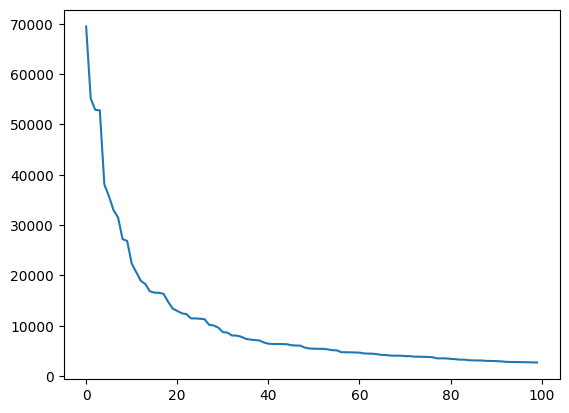

In [69]:

import matplotlib.pyplot as plt

first_100_freqs = [freq for word, freq in freq_dict_sorted[:100]]
plt.plot(first_100_freqs)
plt.show()

Закон Хипса -- обратная сторона закона Ципфа. Он описывает, что чем больше корпус, тем меньше новых слов добавляется с добавлением новых текстов. В какой-то момент корпус насыщается.

## О важности эксплоративного анализа

Но иногда пунктуация бывает и не шумом -- главное отталкиваться от задачи. Что будет если вообще не убирать пунктуацию?

In [70]:
vec = TfidfVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize, token_pattern=None)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     28039
    positive       1.00      1.00      1.00     28670

    accuracy                           1.00     56709
   macro avg       1.00      1.00      1.00     56709
weighted avg       1.00      1.00      1.00     56709



Шок! Стоило оставить пунктуацию -- и все метрики равны 1. Как это получилось? Среди неё были очень значимые токены (как вы думаете, какие?). Найдите фичи с самыми большими коэффициэнтами:

In [71]:
feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]

top_positive_idx = np.argsort(coefs)[-20:][::-1]
top_negative_idx = np.argsort(coefs)[:20]

top_positive = feature_names[top_positive_idx]
top_negative = feature_names[top_negative_idx]

print('Топ положительных фич:')
for feat, coef in zip(top_positive, coefs[top_positive_idx]):
    print(feat, coef)

print('\nТоп отрицательных фич:')
for feat, coef in zip(top_negative, coefs[top_negative_idx]):
    print(feat, coef)

Топ положительных фич:
) 59.04343752488145
d 28.112259407010978
dd 10.839207667438425
^_^ 9.180768750379183
ddd 8.062241792204844
-d 7.500456153776414
* 6.482316041975693
: 6.338431802826892
dddd 3.8689447076262513
ddddd 2.2678856678624837
люблю 1.6701838737065655
ахах 1.5464992599186738
спасибо 1.349157940333176
приятно 1.3193585268829842
dddddd 1.3066917373089169
ахахах 1.2912368899390332
ахаха 1.272685751569211
х 1.2506971377676768
=^_^= 1.1410508060072662
okirilyuk 1.056864442959559

Топ отрицательных фич:
( -59.90505106063773
| -12.03959629223035
о_о -11.535614523581158
o_o -8.659347972518855
-/ -8.640567716013543
to_over_kill -5.336682346950155
cio_optimal -4.859646119362275
rt -4.482905960175944
do_or_die_xxx -4.231171959984586
prisonero_o -3.5422024387993702
reno_oppa -3.1674461643845344
horanso_on -2.5752262957708942
снаступающимтвиттерский -2.5298029371844626
kota_oo_oo -2.2448119251885954
_do_or_die__ -2.202900470082801
o_obnulyay -2.097370201033133
lponomarenko_o -1.9664135

Посмотрим, как один из супер-значительных токенов справится с классификацией безо всякого машинного обучения:

In [72]:
cool_token = top_positive[0]
print(cool_token)

pred = ['positive' if cool_token in tweet else 'negative' for tweet in x_test]
print(classification_report(pred, y_test))

)
              precision    recall  f1-score   support

    negative       1.00      0.85      0.92     32887
    positive       0.83      1.00      0.91     23822

    accuracy                           0.92     56709
   macro avg       0.92      0.93      0.91     56709
weighted avg       0.93      0.92      0.92     56709



## Символьные n-граммы

Теперь в качестве фичей используем, например, униграммы символов:

In [73]:
vec = CountVectorizer(analyzer='char', ngram_range=(1, 1))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99     27957
    positive       1.00      0.99      0.99     28752

    accuracy                           0.99     56709
   macro avg       0.99      0.99      0.99     56709
weighted avg       0.99      0.99      0.99     56709



В общем-то, теперь уже понятно, почему на этих данных здесь 1. Так или инчае, на символах классифицировать тоже можно: для некторых задач (например, для определения языка) фичи-символьные n-граммы решительно рулят.

Ещё одна замечательная особенность фичей-символов: токенизация и лемматизация не нужна, можно использовать такой подход для языков, у которых нет готвых анализаторов.

## Регулярки

(если осталось время)

Вообще, часто бывает так, что для конкретного случая нужен особый способ токенизации, и надо самостоятельно написать регулярку. Или, например, перед работой с текстом, надо почистить его от своеобразного мусора: упоминаний пользователей, url и так далее.

Навык полезный, давайте в нём тоже потренируемся.

In [74]:
import re

### findall
возвращает список всех найденных совпадений

In [75]:
result = re.findall('ab+c.', 'abcdefghijkabcabcxabc')
print(result)

['abcd', 'abca']


Вопрос на внимательность: почему нет abcx?

Потому что re.findall возвращает только непересекающиеся совпадения.

В строке ...abcabcxabc регулярка ab+c. сначала находит abca, и после этого поиск продолжается после уже найденного фрагмента.  
Поэтому вариант abcx, который пересекался бы с уже найденным abca, отдельно уже не попадает в результат.

**Задание**: вернуть список первых двух букв каждого слова в строке, состоящей из нескольких слов.

In [76]:
text = 'Мама мыла раму и окно'
result = re.findall(r'\b\w\w', text)
print(result)

['Ма', 'мы', 'ра', 'ок']


### split
разделяет строку по заданному шаблону


In [77]:
result = re.split(',', 'itsy, bitsy, teenie, weenie')
print(result)

['itsy', ' bitsy', ' teenie', ' weenie']


можно указать максимальное количество разбиений

In [78]:
result = re.split(',', 'itsy, bitsy, teenie, weenie', maxsplit = 2)
print(result)

['itsy', ' bitsy', ' teenie, weenie']


**Задание**: разбейте строку, состоящую из нескольких предложений, по точкам, но не более чем на 3 предложения.

In [79]:
text = 'Это первое предложение. Это второе предложение. Это третье предложение. Это четвертое предложение.'
result = re.split(r'\.\s*', text, maxsplit=2)
print(result)

['Это первое предложение', 'Это второе предложение', 'Это третье предложение. Это четвертое предложение.']


### sub
ищет шаблон в строке и заменяет все совпадения на указанную подстроку

параметры: (pattern, repl, string)

In [80]:
result = re.sub('a', 'b', 'abcabc')
print (result)

bbcbbc


**Задание**: напишите регулярку, которая заменяет все цифры в строке на "DIG".

In [81]:
text = 'У меня 2 яблока, 15 груш и 123 сливы'
result = re.sub(r'\d+', 'DIG', text)
print(result)

У меня DIG яблока, DIG груш и DIG сливы


**Задание**: напишите регулярку, которая убирает url из строки.

In [82]:
text = 'Смотри https://example.com и ещё http://test.ru/page, это полезные ссылки'
result = re.sub(r'https?://\S+|www\.\S+', '', text)
print(result)

Смотри  и ещё  это полезные ссылки


### compile
компилирует регулярное выражение в отдельный объект

In [83]:
# Пример: построение списка всех слов строки:
prog = re.compile('[А-Яа-яё\-]+')
prog.findall("Слова? Да, больше, ещё больше слов! Что-то ещё.")

['Слова', 'Да', 'больше', 'ещё', 'больше', 'слов', 'Что-то', 'ещё']

**Задание**: для выбранной строки постройте список слов, которые длиннее трех символов.

In [84]:
text = "Слова? Да, больше, ещё больше слов! Что-то ещё."
prog = re.compile(r'[А-Яа-яЁё\-]{4,}')
result = prog.findall(text)
print(result)

['Слова', 'больше', 'больше', 'слов', 'Что-то']


**Задание**: вернуть список доменов (@gmail.com) из списка адресов электронной почты:

```
abc.test@gmail.com, xyz@test.in, test.first@analyticsvidhya.com, first.test@rest.biz
```

In [85]:
text = 'abc.test@gmail.com, xyz@test.in, test.first@analyticsvidhya.com, first.test@rest.biz'
result = re.findall(r'@\w+\.\w+', text)
print(result)

['@gmail.com', '@test.in', '@analyticsvidhya.com', '@rest.biz']


Если всё ещё осталось время: [регулярочный кроссворд ¯\_(ツ)_/¯](https://mariolurig.com/crossword/)